# 1. Definición del objetivo

**Objetivo:** clasificar una película como éxito o fracaso financiero usando información disponible antes o al momento del estreno.

Éxito (1): revenue >= 2.5 × budget. Fracaso (0): cualquier otro caso.

# 2. Selección de datos

In [168]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

In [169]:
pd.set_option('display.max_columns', None)

In [170]:
movie_df = pd.read_csv('../datasets/raw/movies_metadata.csv')
print('Dimensiones:', movie_df.shape)
movie_df.head()

Dimensiones: (45466, 24)


/var/folders/h8/vtv9bx_x4lv6302qf1vy44180000gn/T/ipykernel_42477/611568745.py:1: DtypeWarning: Columns (0: popularity) have mixed types. Specify dtype option on import or set low_memory=False.
  movie_df = pd.read_csv('../datasets/raw/movies_metadata.csv')


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,[{'name': 'Twentieth Century Fox Film Corporat...,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"[{'name': 'Sandollar Productions', 'id': 5842}...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [171]:
print('Columns:')
for column in movie_df.columns:
  print(f'- {column}')

Columns:
- adult
- belongs_to_collection
- budget
- genres
- homepage
- id
- imdb_id
- original_language
- original_title
- overview
- popularity
- poster_path
- production_companies
- production_countries
- release_date
- revenue
- runtime
- spoken_languages
- status
- tagline
- title
- video
- vote_average
- vote_count


Revenue se usa solamente para construir el objetivo. Se excluyen vote_average, vote_count y popularity porque pueden incorporar información posterior al estreno.

In [172]:
selected_columns = [
    'budget',
    'revenue',
    'runtime',
    'release_date',
    'genres',
    'belongs_to_collection',
    'production_companies',
    'production_countries',
    'spoken_languages'
]

# 3. Limpieza

Cambiamos los tipos de variables a su respectivo tipo.

In [173]:
print('Antes:')
print(movie_df[selected_columns].dtypes)

# Cambiamos el tipo de variable a su respectivo tipo
for column in ['budget', 'revenue', 'runtime']:
    movie_df[column] = pd.to_numeric(movie_df[column], errors='coerce')
movie_df['release_date'] = pd.to_datetime(movie_df['release_date'], errors='coerce')

print('-'*50)

print('Despues:')
print(movie_df[selected_columns].dtypes)

Antes:
budget                       str
revenue                  float64
runtime                  float64
release_date                 str
genres                       str
belongs_to_collection        str
production_companies         str
production_countries         str
spoken_languages             str
dtype: object
--------------------------------------------------
Despues:
budget                          float64
revenue                         float64
runtime                         float64
release_date             datetime64[us]
genres                              str
belongs_to_collection               str
production_companies                str
production_countries                str
spoken_languages                    str
dtype: object


Eliminamos datos con valores faltantes y duplicados.

In [174]:
print('Valores faltantes:')
print(movie_df[selected_columns].isnull().sum())
print('Filas duplicadas:', movie_df.duplicated().sum())

Valores faltantes:
budget                       3
revenue                      6
runtime                    263
release_date                90
genres                       0
belongs_to_collection    40972
production_companies         3
production_countries         3
spoken_languages             6
dtype: int64
Filas duplicadas: 13


In [175]:
# Los ceros financieros representan datos desconocidos.
movie_df_clean = movie_df.loc[
    (movie_df['budget'] > 0)
    & (movie_df['revenue'] > 0)
    & (movie_df['runtime'] > 0)
    & movie_df['release_date'].notna()
].drop_duplicates(subset='id').copy()


print('Registros limpios:', len(movie_df_clean))

Registros limpios: 5363


Agregamos la variable objetivo en base al si el revenue fue 2.5 veces mayor al presupuesto.

In [176]:
movie_df_clean['success'] = (
    movie_df_clean['revenue'] >= 2.5 * movie_df_clean['budget']
).astype(int)

In [177]:
movie_df_clean['success']

0        1
1        1
3        1
5        1
8        0
        ..
45167    1
45250    0
45409    0
45412    0
45422    0
Name: success, Length: 5363, dtype: int64

# 4. Transformación y normalización

In [178]:
print(f'Min: {min(movie_df_clean['budget'])}')
print(f'Max: {max(movie_df_clean['budget'])}')

Min: 1.0
Max: 380000000.0


Aplicamos logaritmo natural a budget para eliminar las grandes diferencias. Y contamos el numero de elementos de las variables genres, production_companies, production_countries, spoken_languages, y contamos si pertenece a una coleccion o no en lugar de usar un OneHotEncoder o get_dummies para mantener simple el modelo.

In [179]:
def count_items(value):
    if pd.isna(value) or value == '':
        return 0
    try:
        parsed = ast.literal_eval(value) if isinstance(value, str) else value
        return len(parsed) if isinstance(parsed, list) else 0
    except (ValueError, SyntaxError):
        return 0

X = pd.DataFrame(index=movie_df_clean.index)

X['log_budget'] = np.log1p(movie_df_clean['budget'])

X['runtime'] = movie_df_clean['runtime']

X['release_year'] = movie_df_clean['release_date'].dt.year
X['release_month'] = movie_df_clean['release_date'].dt.month

X['genre_count'] = movie_df_clean['genres'].apply(count_items)
X['company_count'] = movie_df_clean['production_companies'].apply(count_items)
X['country_count'] = movie_df_clean['production_countries'].apply(count_items)
X['language_count'] = movie_df_clean['spoken_languages'].apply(count_items)

X['is_collection'] = movie_df_clean['belongs_to_collection'].notna().astype(int)

y = movie_df_clean['success']

print('Dimensiones de X:', X.shape)
X.head()

Dimensiones de X: (5363, 9)


,log_budget,runtime,release_year,release_month,genre_count,company_count,country_count,language_count,is_collection
0,17.216708,81.0,1995,10,3,1,1,1,1
1,17.989898,104.0,1995,12,3,3,1,2,0
3,16.588099,127.0,1995,12,3,1,1,1,0
5,17.909855,170.0,1995,12,4,3,1,2,0
8,17.370859,106.0,1995,12,3,3,1,1,0


Dividimos los datos de entrenamiento y prueba y escalamos los datos.

In [180]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Entrenamiento:', X_train.shape)
print('Prueba:', X_test.shape)

Entrenamiento: (4290, 9)
Prueba: (1073, 9)


# 5. Minería de datos

Se utiliza **Random Forest**, un conjunto de árboles de decisión capaz de modelar relaciones no lineales entre las características de las películas.

In [181]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 6. Evaluación

In [182]:
y_probability = model.predict_proba(X_test)[:, 1]
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred):.3f}')
print(f'F1-score:  {f1_score(y_test, y_pred):.3f}')
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred, target_names=['Fracaso', 'Éxito']))

Accuracy:  0.702
Precision: 0.658
Recall:    0.635
F1-score:  0.646

Reporte de clasificación:
              precision    recall  f1-score   support

     Fracaso       0.73      0.75      0.74       613
       Éxito       0.66      0.63      0.65       460

    accuracy                           0.70      1073
   macro avg       0.70      0.69      0.69      1073
weighted avg       0.70      0.70      0.70      1073



# 7. Interpretación

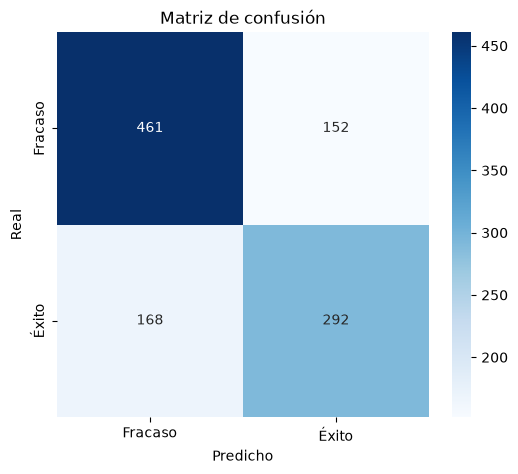

In [187]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fracaso', 'Éxito'],
            yticklabels=['Fracaso', 'Éxito'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión')
plt.show()

In [188]:
results = movie_df_clean.loc[X_test.index, ['title', 'budget', 'revenue']].copy()
results['Clase real'] = y_test.map({0: 'Fracaso', 1: 'Éxito'})
results['Predicción'] = pd.Series(y_pred, index=X_test.index).map({0: 'Fracaso', 1: 'Éxito'})
results['Resultado'] = np.where(
    results['Clase real'] == results['Predicción'], 'Correcta', 'Incorrecta'
)
results.head(15)

,title,budget,revenue,Clase real,Predicción,Resultado
11495,Happily N'Ever After,47000000.0,38085778.0,Fracaso,Éxito,Incorrecta
43471,Bizim Aile,65700.0,214600.0,Éxito,Éxito,Correcta
3880,The Living Daylights,40000000.0,191185897.0,Éxito,Éxito,Correcta
37863,Sing Street,4000000.0,13624522.0,Éxito,Fracaso,Incorrecta
25393,Unbroken,65000000.0,163442937.0,Éxito,Fracaso,Incorrecta
36246,Embrace of the Serpent,1400000.0,1320005.0,Fracaso,Fracaso,Correcta
2806,Hang 'em High,1800000.0,6800000.0,Éxito,Éxito,Correcta
7720,Soul Plane,16000000.0,14822346.0,Fracaso,Fracaso,Correcta
7109,Catch That Kid,18000000.0,16702864.0,Fracaso,Fracaso,Correcta
21462,Chennai Express,18000000.0,62000000.0,Éxito,Éxito,Correcta


log_budget        0.207521
runtime           0.188557
release_year      0.188108
release_month     0.108951
company_count     0.088004
genre_count       0.069739
is_collection     0.068210
language_count    0.047139
country_count     0.033772
Name: Importancia, dtype: float64


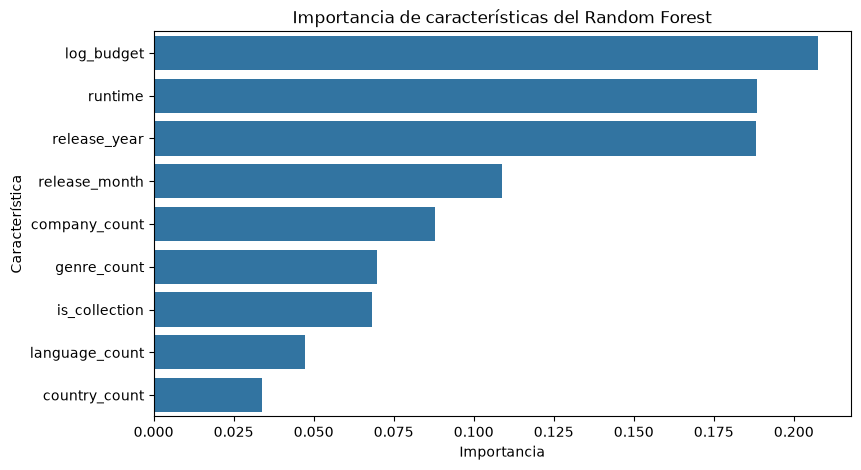

In [189]:
# Importancia de las características utilizadas por Random Forest.
feature_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns,
    name='Importancia'
).sort_values(ascending=False)

print(feature_importance)

plt.figure(figsize=(9, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.title('Importancia de características del Random Forest')
plt.show()